# KK1 – Palmer Penguins: What separates three penguin species?

**Dataset:** Palmer Penguins — each row is one penguin measured at Palmer Station (Antarctica), 2007–2009.  
**Question:** Which measurements best separate Adelie, Chinstrap, and Gentoo?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

In [3]:
COLORS = {'Adelie': '#4C72B0', 'Chinstrap': '#DD8452', 'Gentoo': '#55A868'}
print('Libraries loaded.')

Libraries loaded.


## 2. Load and inspect the data

In [ ]:
df = pd.read_csv('penguins.csv')

print('Shape:', df.shape)
print()
df.info()
print()
df.describe()

Shape: (344, 8)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [ ]:
# Missing values per column
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

## 3. Clean the data (with justification)

- **Drop rows** where all measurements are missing — we cannot analyze without them.
- **Keep rows** where only `sex` is missing — not needed for our charts.
- **Keep** island and year unchanged.

In [ ]:
measure_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

df = df.dropna(subset=measure_cols, how='all').copy()
print('Rows after cleaning:', len(df))
df.isna().sum()

Rows after cleaning: 342


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
year                 0
dtype: int64

## 4. Visualizations

### Chart 1 — How many per species?
**Question:** How are the three species distributed?  
**Chart type:** Bar chart (counts per category).

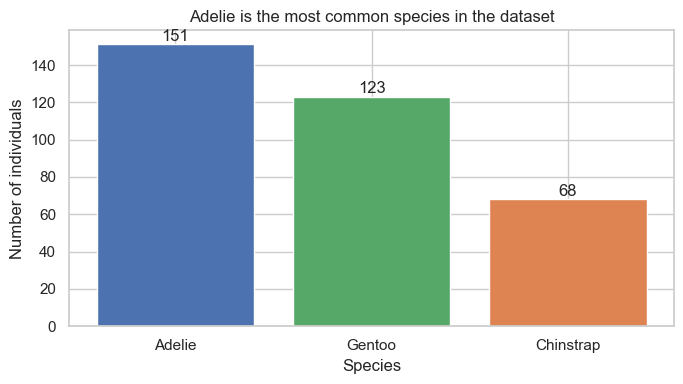

In [ ]:
counts = df['species'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index])

ax.set_title('Adelie is the most common species in the dataset')
ax.set_xlabel('Species')
ax.set_ylabel('Number of individuals')
ax.set_ylim(0)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

Adelie has the most observations. All three species are present in the data.

### Chart 2 — Body mass per species
**Question:** Does weight differ between species?  
**Chart type:** Box plot (compare distributions across groups).

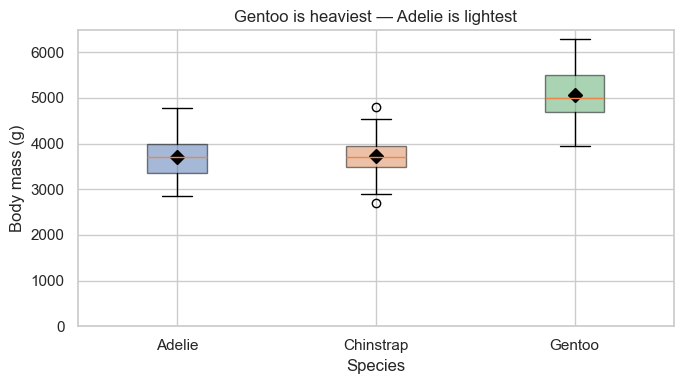

species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

species_list = ['Adelie', 'Chinstrap', 'Gentoo']
data = [df.loc[df['species'] == sp, 'body_mass_g'] for sp in species_list]

bp = ax.boxplot(data, labels=species_list, patch_artist=True)
for patch, sp in zip(bp['boxes'], species_list):
    patch.set_facecolor(COLORS[sp])
    patch.set_alpha(0.5)

means = df.groupby('species')['body_mass_g'].mean()
for i, sp in enumerate(species_list, start=1):
    ax.plot(i, means[sp], marker='D', color='black', markersize=7)

ax.set_title('Gentoo is heaviest — Adelie is lightest')
ax.set_xlabel('Species')
ax.set_ylabel('Body mass (g)')
ax.set_ylim(0)

plt.tight_layout()
plt.show()

means.round(0)

Gentoo is clearly heavier. Chinstrap sits between Adelie and Gentoo.

### Chart 3 — Bill length vs bill depth per species

**Question:** Can the species be distinguished based solely on bill measurements?

**Step 1 — Choose the chart type:**
Scatterplot. Each dot is one penguin plotted on two axes (bill length × bill depth). This lets us see whether individuals naturally group into clusters by species.

**Step 2 — Why not a bar chart or boxplot?**
Bar charts and boxplots summarise one variable at a time. To see whether *two* measurements together separate the species, we need both dimensions plotted simultaneously — only a scatterplot shows this.

**Step 3 — What to look for:**
If the three species form tight, non-overlapping clouds of points, the bill measurements are strong species markers. If the clouds overlap heavily, the measurements alone are not enough to tell the species apart.

**Step 4 — Colour coding:**
Each species is assigned a distinct colour so clusters are immediately visible without needing to read a data table.

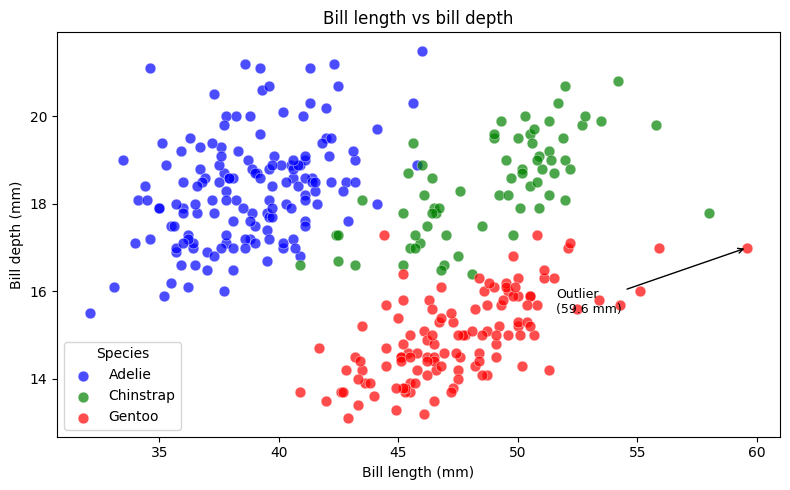

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")

COLORS = {
    "Adelie": "blue",
    "Chinstrap": "green",
    "Gentoo": "red"
}
df = df.dropna(subset=["bill_length_mm", "bill_depth_mm", "species"])

fig, ax = plt.subplots(figsize=(8, 5))

for sp in ['Adelie', 'Chinstrap', 'Gentoo']:
    sub = df[df['species'] == sp]
    ax.scatter(sub['bill_length_mm'], sub['bill_depth_mm'],
               color=COLORS[sp], label=sp, alpha=0.7,
               edgecolors='white', linewidths=0.4, s=60)

outlier = df.loc[df['bill_length_mm'].idxmax()]
ax.annotate(f"Outlier\n({outlier['bill_length_mm']} mm)",
            xy=(outlier['bill_length_mm'], outlier['bill_depth_mm']),
            xytext=(outlier['bill_length_mm'] - 8, outlier['bill_depth_mm'] - 1.5),
            fontsize=9,
            arrowprops=dict(arrowstyle='->'))

ax.set_title('Bill length vs bill depth')
ax.set_xlabel('Bill length (mm)')
ax.set_ylabel('Bill depth (mm)')
ax.legend(title='Species')

plt.tight_layout()
plt.show()